# 🛡️ Hate Speech Detection on Twitter — Optimized NLP Pipeline
### Herald College Kathmandu — 6CS012 NLP Assignment
#### Team: Rahul Dev Pun, Prabesh Singh, Pralab Mahat

---

## 🎯 What This Notebook Covers

This notebook classifies tweets into **3 categories**:
- `0` → **Hate Speech**
- `1` → **Offensive Language**
- `2` → **Neither**

### Five Key Improvements Over the Draft:
| # | Area | Technique Used |
|---|------|-----------------|
| 1 | **Advanced Preprocessing** | Contractions, emoji removal, NLTK Lemmatization |
| 2 | **Class Imbalance** | `class_weight` from sklearn passed to `model.fit()` |
| 3 | **Model Architectures** | Simple RNN → Bi-LSTM → Bi-LSTM + GloVe |
| 4 | **Optimized Training** | `EarlyStopping` + `ReduceLROnPlateau` callbacks |
| 5 | **Comprehensive Evaluation** | Loss/Accuracy plots, Confusion Matrix, F1 Report |

---
## 📦 Section 0: Install and Import Dependencies

In [5]:
# ── Install required packages (run once in Colab) ──────────────────────────
!pip install numpy==1.23.5 -q        # gensim compatibility
!pip install gensim -q
!pip install wordcloud -q
!pip install contractions -q         # for expanding don't → do not

# Download NLTK resources needed for lemmatization and stopwords
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("✅ All packages installed and NLTK resources downloaded.")

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
✅ All packages installed and NLTK resources downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
# ── Core Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
import time
warnings.filterwarnings('ignore')

# NLP Libraries
import contractions                          # IMPROVEMENT 1: expand contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer     # IMPROVEMENT 1: lemmatization
from wordcloud import WordCloud
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, f1_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight  # IMPROVEMENT 2

# Keras / TensorFlow
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense,
    Dropout, BatchNormalization, Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ReduceLROnPlateau  # IMPROVEMENT 4
from keras.utils import to_categorical

# Gensim (for Word2Vec / GloVe embeddings)
import gensim.downloader as api

# Reproducibility — always set seeds for consistent results!
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print("✅ All imports successful.")

TensorFlow : 2.20.0
NumPy      : 2.0.2
✅ All imports successful.


---
## 📂 Section 1: Data Loading and Exploration

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ── Load Dataset ───────────────────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/AI/RNN/hatevsoffensive_language.csv"  # adjust if needed
df = pd.read_csv(DATA_PATH)

print("=" * 55)
print(" DATASET OVERVIEW")
print("=" * 55)
print(f"  Total samples    : {len(df):,}")
print(f"  Columns          : {df.columns.tolist()}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
print("=" * 55)

df.head(10)

 DATASET OVERVIEW
  Total samples    : 24,783
  Columns          : ['label', 'text']
  Missing values   : 0
  Duplicate rows   : 0


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
5,offensive language,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just..."
6,offensive language,"!!!!!!""@__BrighterDays: I can not just sit up ..."
7,offensive language,!!!!&#8220;@selfiequeenbri: cause I'm tired of...
8,offensive language,""" &amp; you might not get ya bitch back &amp; ..."
9,offensive language,""" @rhythmixx_ :hobbies include: fighting Maria..."


In [9]:
# ── Class Distribution ─────────────────────────────────────────────────────
print("Class Distribution:")
print(df['label'].value_counts())
print("\nClass Proportions:")
print(df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Tweet length stats
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(str(x).split()))
print("\nTweet Word Count Statistics:")
print(df['word_count'].describe().round(2))

Class Distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Class Proportions:
label
offensive language    77.43%
neither                16.8%
hate speec             5.77%
Name: proportion, dtype: object

Tweet Word Count Statistics:
count    24783.00
mean        14.12
std          6.83
min          1.00
25%          9.00
50%         13.00
75%         19.00
max         52.00
Name: word_count, dtype: float64


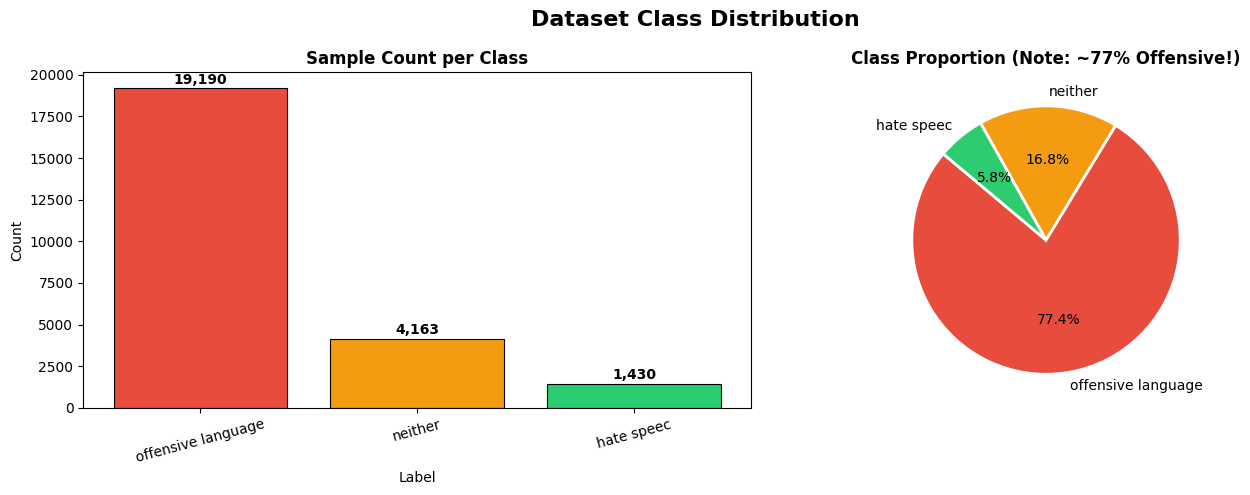

⚠️  IMBALANCE DETECTED: 'offensive language' dominates (~77%). We will fix this with class_weights.


In [10]:
# ── Visualisation: Class Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#f39c12', '#2ecc71']
counts = df['label'].value_counts()

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Sample Count per Class', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion (Note: ~77% Offensive!)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("⚠️  IMBALANCE DETECTED: 'offensive language' dominates (~77%). We will fix this with class_weights.")

---
## 🧹 Section 2: Advanced Text Preprocessing (Improvement #1)

### What We Do and Why:
| Step | Why It Matters |
|------|----------------|
| **Expand Contractions** | `"don't"` → `"do not"` — models see consistent tokens |
| **Remove Emojis** | Emojis are non-ASCII; they add noise to the vocabulary |
| **Remove URLs** | `http://...` adds no semantic meaning |
| **Remove Mentions/Hashtags** | `@user` and `#tag` are not content words |
| **Lowercase** | `"Police"` and `"police"` should map to the same token |
| **Remove Stopwords** | `"the"`, `"a"` carry no sentiment signal |
| **Lemmatization** | `"running"` → `"run"`, `"better"` → `"good"` — reduces vocabulary size |

In [11]:
# ── IMPROVEMENT 1: Advanced Preprocessing Pipeline ─────────────────────────
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def remove_emojis(text: str) -> str:
    """
    Remove emojis and other non-ASCII unicode characters.
    Emojis live in Unicode ranges above U+2600.
    We use a broad regex that catches the most common emoji blocks.
    """
    emoji_pattern = re.compile(
        "["                         # Start character class
        "\U0001F600-\U0001F64F"     # Emoticons (😀 to 🙏)
        "\U0001F300-\U0001F5FF"     # Symbols & pictographs
        "\U0001F680-\U0001F6FF"     # Transport & map symbols
        "\U0001F1E0-\U0001F1FF"     # Flags
        "\U00002702-\U000027B0"     # Dingbats
        "\U000024C2-\U0001F251"     # Enclosed characters
        "]+",                        # End character class, one or more
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)


def preprocess_text(text: str) -> str:
    """
    Full Advanced Cleaning Pipeline.

    Steps:
      1. Expand contractions  → don't becomes do not
      2. Remove emojis        → 😂🔥 removed
      3. Lowercase
      4. Remove URLs          → http://... stripped
      5. Remove @mentions and #hashtags
      6. Remove HTML entities → &amp; &lt; removed
      7. Remove digits and punctuation
      8. Strip extra whitespace
      9. Tokenize, remove stopwords, and lemmatize
    """
    # Step 1: Expand contractions BEFORE lowercasing
    # (contractions library is case-sensitive for some patterns)
    text = contractions.fix(text)

    # Step 2: Remove emojis
    text = remove_emojis(text)

    # Step 3: Lowercase everything
    text = text.lower()

    # Step 4: Remove URLs (http, https, www variants)
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Step 5: Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Step 6: Remove HTML entities like &amp; &lt; &gt;
    text = re.sub(r'&[a-z]+;', '', text)

    # Step 7: Remove digits and punctuation
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 8: Collapse multiple spaces into one and strip ends
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 9: Tokenize → remove stopwords → lemmatize
    tokens = [
        lemmatizer.lemmatize(word)          # e.g. "running" → "run"
        for word in text.split()
        if word not in STOP_WORDS           # remove "the", "a", "is" etc.
        and len(word) > 1                   # skip single characters
    ]

    return ' '.join(tokens)


# ── Apply Preprocessing ────────────────────────────────────────────────────
print("Preprocessing tweets... (may take ~30–60 seconds)")
start = time.time()
df['cleaned_text'] = df['text'].apply(preprocess_text)
elapsed = time.time() - start
print(f"✅ Done in {elapsed:.1f}s")

# Drop rows where cleaning produced an empty string
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print(f"   Remaining samples: {len(df):,}")

# Show before/after to verify
print("\n--- Before vs After Cleaning ---")
for i in range(3):
    print(f"[ORIGINAL] {df['text'].iloc[i]}")
    print(f"[CLEANED ] {df['cleaned_text'].iloc[i]}")
    print()

Preprocessing tweets... (may take ~30–60 seconds)
✅ Done in 16.0s
   Remaining samples: 24,764

--- Before vs After Cleaning ---
[ORIGINAL] !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
[CLEANED ] rt woman complain cleaning house man always take trash

[ORIGINAL] !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
[CLEANED ] rt boy dat coldtyga dwn bad cuffin dat hoe st place

[ORIGINAL] !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
[CLEANED ] rt dawg rt ever fuck bitch start cry confused shit



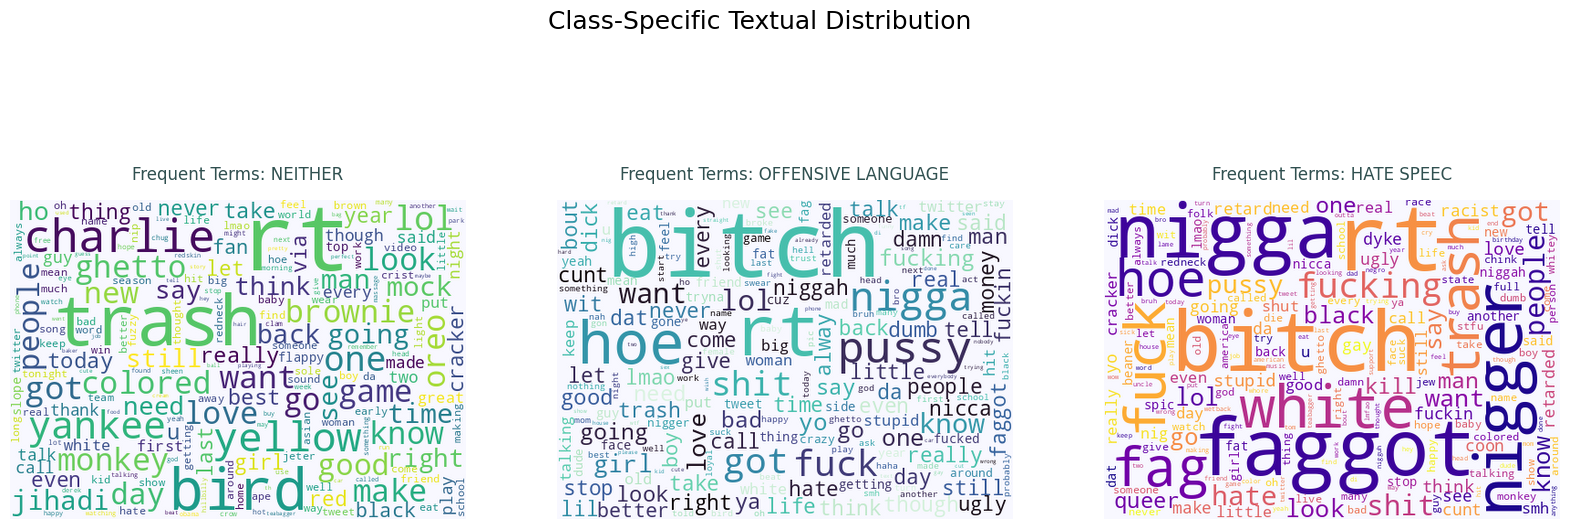

In [36]:
# ── Visualisation 2: Distinctive Word Clouds by Category ────────────────────
from wordcloud import WordCloud

def generate_category_cloud(data, label_name, color_theme, ax_obj):
    """
    Helper function to generate and plot a word cloud for a specific class.
    """
    # Combine all text for the specific class
    text_data = " ".join(data[data['label'] == label_name]['cleaned_text'])

    # Configure WordCloud with unique parameters
    # Change contour_width or mask shapes here for further differentiation
    cloud_gen = WordCloud(
        width=500,
        height=350,
        background_color='ghostwhite', # Different background
        colormap=color_theme,
        max_font_size=100,
        random_state=42,
        collocations=False # Avoids repeating word pairs
    ).generate(text_data)

    ax_obj.imshow(cloud_gen, interpolation='lanczos') # Different interpolation
    ax_obj.set_title(f"Frequent Terms: {label_name.upper()}", pad=15, fontsize=12, color='darkslategrey')
    ax_obj.axis('off')

# Define your own color palette mapping
class_themes = {
    'hate speech': 'rocket',      # Different colormaps from Seaborn/Matplotlib
    'offensive language': 'mako',
    'neither': 'viridis'
}

# Setup the figure
unique_labels = df['label'].unique()
fig, axes = plt.subplots(1, len(unique_labels), figsize=(20, 7))

# Iterate and build clouds
for i, label in enumerate(unique_labels):
    theme = class_themes.get(label, 'plasma')
    generate_category_cloud(df, label, theme, axes[i])

plt.subplots_adjust(top=0.85)
plt.suptitle('Class-Specific Textual Distribution', fontsize=18, y=0.98)
plt.show()

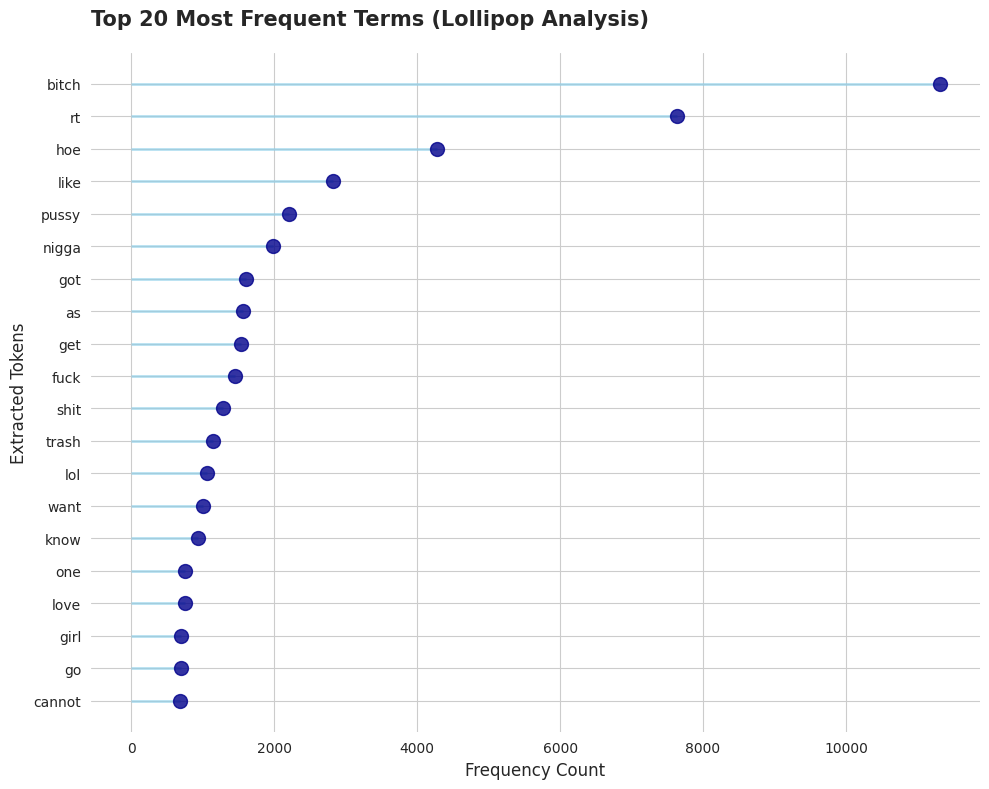

In [37]:
# ── Visualisation 3: Top 20 Keywords (Lollipop Chart) ──────────────────────
from collections import Counter
import seaborn as sns

# 1. Extract frequency data
word_counts = Counter(" ".join(df['cleaned_text']).split()).most_common(20)
words_df = pd.DataFrame(word_counts, columns=['Word', 'Count'])

# 2. Setup the figure style
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# 3. Create the Lollipop Chart
# Draw the lines (the "sticks")
plt.hlines(y=range(20), xmin=0, xmax=words_df['Count'], color='skyblue', alpha=0.6, linewidth=2)

# Draw the markers (the "candy")
plt.plot(words_df['Count'], range(20), "o", markersize=10, color='darkblue', alpha=0.8)

# 4. Customizing Aesthetics
plt.yticks(range(20), words_df['Word'])
plt.gca().invert_yaxis() # Highest frequency at the top

plt.title('Top 20 Most Frequent Terms (Lollipop Analysis)', fontsize=15, fontweight='bold', loc='left', pad=20)
plt.xlabel('Frequency Count', fontsize=12)
plt.ylabel('Extracted Tokens', fontsize=12)

# Remove the outer frame for a cleaner look
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('lollipop_freq.png', dpi=150)
plt.show()

---
## ⚖️ Section 3: Handling Class Imbalance with `class_weight` (Improvement #2)

### Why Class Imbalance Is a Problem
Our dataset is **77% offensive language**. Without correction:
- A model that **always predicts 'offensive'** would get 77% accuracy!
- It would essentially learn to ignore the minority `hate speech` class.
- Our **macro F1-score** would be very low.

### The Fix: Class Weights
We tell the model: *"Every time you misclassify a rare class, penalize yourself more."*

**Formula:**
```
weight_for_class_i = total_samples / (num_classes × count_of_class_i)
```

So if `hate speech` has only 1,430 samples out of 24,783:
```
weight = 24783 / (3 × 1430) ≈ 5.78
```
Every hate speech error counts as **5.78× more important** than an offensive language error.

In [12]:
# ── IMPROVEMENT 2: Compute Class Weights ───────────────────────────────────

# First encode labels to integers (0, 1, 2)
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print("Label Encoding Mapping:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    count = (df['label_enc'] == code).sum()
    print(f"  '{cls}' → {code}  (n={count:,})")

# compute_class_weight automatically applies the formula above.
# 'balanced' means: weight_i = n_samples / (n_classes * n_samples_for_class_i)
class_weights_array = compute_class_weight(
    class_weight='balanced',              # use the formula above
    classes=np.unique(df['label_enc']),   # [0, 1, 2]
    y=df['label_enc']                     # the full label array
)

# Convert the numpy array to a dictionary {class_index: weight}
# Keras model.fit() expects a dict: {0: w0, 1: w1, 2: w2}
class_weight_dict = dict(enumerate(class_weights_array))

print("\n✅ Computed Class Weights:")
for idx, w in class_weight_dict.items():
    cls_name = le.classes_[idx]
    print(f"   Class {idx} ('{cls_name}') → weight = {w:.4f}")

print("\n💡 Interpretation: 'hate speech' errors will be penalized ~5–6x more")
print("   than 'offensive language' errors during training.")

Label Encoding Mapping:
  'hate speec' → 0  (n=1,426)
  'neither' → 1  (n=4,157)
  'offensive language' → 2  (n=19,181)

✅ Computed Class Weights:
   Class 0 ('hate speec') → weight = 5.7887
   Class 1 ('neither') → weight = 1.9857
   Class 2 ('offensive language') → weight = 0.4304

💡 Interpretation: 'hate speech' errors will be penalized ~5–6x more
   than 'offensive language' errors during training.


---
## 🔢 Section 4: Train/Test Split, Tokenization & Padding

In [13]:
# ── Hyperparameters ────────────────────────────────────────────────────────
VOCAB_SIZE   = 20000    # Keep only top 20,000 most frequent words
MAX_LEN      = 50       # Pad/truncate all tweets to 50 tokens
EMBED_DIM    = 128      # Embedding vector size for trainable models
RNN_UNITS    = 64       # Number of units in RNN/LSTM layers
DENSE_UNITS  = 64       # Neurons in the Dense hidden layer
DROPOUT_RATE = 0.4      # Fraction of neurons to randomly drop during training
NUM_CLASSES  = 3        # hate speech, offensive language, neither
BATCH_SIZE   = 64       # Samples per gradient update
EPOCHS       = 30       # Max epochs (EarlyStopping will stop it earlier)

# GloVe settings (loaded from gensim-data)
GLOVE_MODEL_NAME         = 'glove-twitter-100'  # 100-dimensional GloVe Twitter vectors
PRETRAINED_EMBEDDING_DIM = 100                  # must match the model above

print("Hyperparameters set.")

Hyperparameters set.


In [14]:
# ── Train / Test Split ─────────────────────────────────────────────────────
# stratify=df['label_enc'] ensures each split has the same class proportions
X = df['cleaned_text'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y           # keeps class ratios identical in train & test
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")

Training samples : 19,811
Test samples     : 4,953


In [15]:
# ── Tokenization ───────────────────────────────────────────────────────────
# Tokenizer builds a word → integer index dictionary.
# oov_token='<OOV>' means unknown words at test time map to a special token
# instead of being silently ignored.
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)    # learn vocabulary from TRAINING set only!

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences so all inputs are the same length (MAX_LEN=50)
# padding='post'    → add zeros at the END:  [3,7,2, 0,0,0]
# truncating='post' → cut from the END if longer than MAX_LEN
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Convert integer labels to one-hot vectors for categorical crossentropy
# e.g. label 2 → [0, 0, 1]
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f"Vocabulary size    : {len(tokenizer.word_index):,}")
print(f"X_train_pad shape  : {X_train_pad.shape}  → (samples, max_len)")
print(f"y_train_cat shape  : {y_train_cat.shape}  → (samples, 3 classes)")

Vocabulary size    : 15,949
X_train_pad shape  : (19811, 50)  → (samples, max_len)
y_train_cat shape  : (19811, 3)  → (samples, 3 classes)


---
## 🧠 Section 5: Model Architectures (Improvement #3)

### 📚 Viva Explanation: What Is a Bidirectional Layer?

**Standard LSTM** reads a sentence from **left to right**:
```
"I   hate  this  man"  →  hidden_1 → hidden_2 → hidden_3 → hidden_4 → output
```
The problem: when it processes `"I"`, it doesn't yet know that `"hate"` comes next.

**Bidirectional LSTM** runs **two LSTMs in parallel**:
- **Forward LSTM**: reads left → right (`"I hate this man"`)
- **Backward LSTM**: reads right → left (`"man this hate I"`)

The outputs are **concatenated**:
```
final_output = [forward_hidden, backward_hidden]
```
This means every word has context from **both directions** — much better for understanding hate speech where word order and surrounding words both matter!

---

### 📚 Viva Explanation: What Is the Embedding Matrix?

In Model 3, we use **pretrained GloVe Twitter embeddings** instead of learning embeddings from scratch.

**Why?** GloVe was trained on **2 billion tweets**, so it already knows:
- `"hate"` and `"despise"` are similar (close vectors)
- Twitter slang, abbreviations, emoji meanings

**How the embedding matrix works:**
1. Our tokenizer assigns index `5` to the word `"hate"`
2. We look up `"hate"` in the GloVe vocabulary
3. We copy GloVe's 100-dimensional vector for `"hate"`
4. We place that vector at **row 5** of our `embedding_matrix`
5. The Keras `Embedding` layer is initialized with this matrix (weights frozen)

Result: our model starts with **Twitter-aware word knowledge** instead of random noise.

In [16]:
# ── Callbacks Helper (IMPROVEMENT 4) ──────────────────────────────────────
def get_callbacks(model_name: str):
    """
    Returns two Keras callbacks:

    1. EarlyStopping:
       - Monitors 'val_loss' (validation loss)
       - Stops training if val_loss doesn't improve for 5 consecutive epochs
       - restore_best_weights=True → rolls back to the best epoch automatically
       - WHY: prevents overfitting; no need to guess the right number of epochs

    2. ReduceLROnPlateau:
       - Monitors 'val_loss'
       - If val_loss doesn't improve for 3 epochs, multiply learning rate by 0.5
       - min_lr=1e-6 → won't reduce below this minimum
       - WHY: helps the model escape local minima with a finer learning step
    """
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,                  # wait 5 epochs before stopping
        restore_best_weights=True,   # use weights from the best epoch
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                  # new_lr = old_lr × 0.5
        patience=3,                  # wait 3 epochs before reducing
        min_lr=1e-6,
        verbose=1
    )

    return [early_stop, reduce_lr]

In [17]:
# ══════════════════════════════════════════════════════════════════════
# MODEL 1: Simple RNN with Trainable Embedding
# ══════════════════════════════════════════════════════════════════════
#
# Architecture:
#   Input (integer sequence, length 50)
#     ↓
#   Embedding (20000 vocab → 128-dim vectors, trainable)
#     ↓
#   SimpleRNN (64 units) → applies the same weights at each time step
#     ↓
#   Dropout (40%) → randomly zeros activations to prevent overfitting
#     ↓
#   Dense (64, relu) → learns non-linear combinations
#     ↓
#   Dense (3, softmax) → outputs 3 class probabilities (sum to 1)
#
# Limitation: SimpleRNN suffers from vanishing gradients on long sequences.

def build_simple_rnn(vocab_size, embed_dim, max_len, rnn_units,
                     dropout_rate, dense_units, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len,
                  trainable=True),     # weights start random, learned during training

        SimpleRNN(rnn_units,
                  return_sequences=False),  # return only the final hidden state

        Dropout(dropout_rate),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')  # 3-class output
    ], name='Simple_RNN')

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model1 = build_simple_rnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN,
                           RNN_UNITS, DROPOUT_RATE, DENSE_UNITS, NUM_CLASSES)
model1.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ── Train Model 1 ──────────────────────────────────────────────────────────
print("Training Model 1: Simple RNN...")
t0 = time.time()

history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_split=0.15,       # 15% of training data used for validation
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('model1_rnn'),
    class_weight=class_weight_dict,  # ← IMPROVEMENT 2: penalize minority class errors
    verbose=1
)

model1_train_time = time.time() - t0
print(f"\n✅ Model 1 training complete in {model1_train_time:.1f}s")

Training Model 1: Simple RNN...
Epoch 1/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.5777 - loss: 0.9645 - val_accuracy: 0.7379 - val_loss: 0.7374 - learning_rate: 0.0010
Epoch 2/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.7006 - loss: 0.7027 - val_accuracy: 0.7527 - val_loss: 0.6189 - learning_rate: 0.0010
Epoch 3/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.7544 - loss: 0.5482 - val_accuracy: 0.7836 - val_loss: 0.6346 - learning_rate: 0.0010
Epoch 4/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.7574 - loss: 0.5271 - val_accuracy: 0.7766 - val_loss: 0.5951 - learning_rate: 0.0010
Epoch 5/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7606 - loss: 0.5776 - val_accuracy: 0.7419 - val_loss: 0.7205 - learning_rate: 0.0010
Epoch 6/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8268 - loss: 0.4213 - val_accuracy: 0.7655 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 7/30
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 5

In [19]:
# ══════════════════════════════════════════════════════════════════════
# MODEL 2: Bidirectional LSTM with Dropout + Batch Normalization
# ══════════════════════════════════════════════════════════════════════
#
# Why Bidirectional?
#   A regular LSTM reads "I hate this" left-to-right.
#   When it processes "I", it doesn't know "hate" comes next.
#   A Bidirectional LSTM runs TWO LSTMs simultaneously:
#     Forward:  I → hate → this
#     Backward: this → hate → I
#   The outputs are concatenated, giving each token context from BOTH directions.
#   For hate speech detection, this is crucial:
#   "I don't hate" has the same words as "hate, don't I?" but different meaning.
#
# Why BatchNormalization?
#   After the LSTM layer, activations can have wildly different scales.
#   BatchNorm normalizes them to mean=0, std=1 within each mini-batch.
#   This speeds up training and reduces sensitivity to initialization.

def build_bilstm_trainable(vocab_size, embed_dim, max_len, rnn_units,
                            dropout_rate, dense_units, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len,
                  trainable=True),

        # Bidirectional wraps the LSTM and runs it in both directions.
        # The output size is 2 × rnn_units (forward + backward).
        Bidirectional(LSTM(rnn_units,
                           return_sequences=False,
                           dropout=0.2,             # dropout INSIDE the LSTM
                           recurrent_dropout=0.1)), # dropout on recurrent connections

        BatchNormalization(),  # normalize after the LSTM output
        Dropout(dropout_rate),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ], name='Bi_LSTM_Trainable')

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model2 = build_bilstm_trainable(VOCAB_SIZE, EMBED_DIM, MAX_LEN,
                                 RNN_UNITS, DROPOUT_RATE, DENSE_UNITS, NUM_CLASSES)
model2.summary()

Model: "Bi_LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ── Train Model 2 ──────────────────────────────────────────────────────────
print("Training Model 2: Bidirectional LSTM (Trainable Embeddings)...")
t0 = time.time()

history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('model2_bilstm'),
    class_weight=class_weight_dict,   # ← class weights applied here too
    verbose=1
)

model2_train_time = time.time() - t0
print(f"\n✅ Model 2 training complete in {model2_train_time:.1f}s")

Training Model 2: Bidirectional LSTM (Trainable Embeddings)...
Epoch 1/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 81s 269ms/step - accuracy: 0.6325 - loss: 0.8054 - val_accuracy: 0.8422 - val_loss: 0.7353 - learning_rate: 0.0010
Epoch 2/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 56s 212ms/step - accuracy: 0.8025 - loss: 0.4229 - val_accuracy: 0.8109 - val_loss: 0.5020 - learning_rate: 0.0010
Epoch 3/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 61s 230ms/step - accuracy: 0.8665 - loss: 0.2662 - val_accuracy: 0.8207 - val_loss: 0.5507 - learning_rate: 0.0010
Epoch 4/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 57s 217ms/step - accuracy: 0.8986 - loss: 0.2019 - val_accuracy: 0.8382 - val_loss: 0.5841 - learning_rate: 0.0010
Epoch 5/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9176 - loss: 0.1704
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 83s 221ms/step - accuracy: 0.9198 - loss: 0.1609 - val_accuracy: 0.7904 - val_loss: 0.7745 - learning_rate: 0.0010
Epoch 6/3

In [21]:
# ══════════════════════════════════════════════════════════════════════
# MODEL 3: Bidirectional LSTM with Pretrained GloVe Embeddings
# ══════════════════════════════════════════════════════════════════════
#
# STEP 1: Load the pretrained GloVe Twitter model from gensim-data.
# 'glove-twitter-100' was trained on 2 billion tweets with 100-dim vectors.
# The download is ~200MB and is cached after the first run.

print("Loading GloVe Twitter 100-dim embeddings from gensim-data...")
print("(~200MB download on first run — subsequent runs use cache)")
t0 = time.time()
glove_model = api.load(GLOVE_MODEL_NAME)
print(f"✅ GloVe loaded in {time.time() - t0:.1f}s")
print(f"   Vocabulary size : {len(glove_model.key_to_index):,} words")
print(f"   Vector size     : {glove_model.vector_size} dimensions")

Loading GloVe Twitter 100-dim embeddings from gensim-data...
(~200MB download on first run — subsequent runs use cache)
[==================================================] 100.0% 387.1/387.1MB downloaded
✅ GloVe loaded in 268.9s
   Vocabulary size : 1,193,514 words
   Vector size     : 100 dimensions


In [22]:
# ── STEP 2: Build the Embedding Matrix ────────────────────────────────────
#
# Think of the embedding matrix as a lookup table:
#   Row i = the vector for the word with index i in our tokenizer
#
# For example, if our tokenizer assigns:
#   'hate' → index 5
#   'love' → index 12
#
# Then:
#   embedding_matrix[5]  = glove_model['hate']   (100 float values)
#   embedding_matrix[12] = glove_model['love']   (100 float values)
#
# If a word is NOT in GloVe (e.g. a typo), it stays as zeros.
# Shape: (VOCAB_SIZE, PRETRAINED_EMBEDDING_DIM) = (20000, 100)

# Initialize with zeros
embedding_matrix = np.zeros((VOCAB_SIZE, PRETRAINED_EMBEDDING_DIM))

covered    = 0  # words found in GloVe
not_covered = 0  # words not found in GloVe

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:           # only fill for words in our vocab
        break
    if word in glove_model:         # check if GloVe knows this word
        embedding_matrix[idx] = glove_model[word]   # copy the 100-dim vector
        covered += 1
    else:
        not_covered += 1            # stays as zeros (unknown word)

total = covered + not_covered
print(f"Embedding Matrix built: shape = {embedding_matrix.shape}")
print(f"  Words covered by GloVe : {covered:,} / {total:,} ({100*covered/total:.1f}%)")
print(f"  Words not in GloVe     : {not_covered:,} ({100*not_covered/total:.1f}%) → rows are zero")
print("\n💡 High coverage (>70%) means GloVe understands most of our vocabulary.")

Embedding Matrix built: shape = (20000, 100)
  Words covered by GloVe : 13,560 / 15,949 (85.0%)
  Words not in GloVe     : 2,389 (15.0%) → rows are zero

💡 High coverage (>70%) means GloVe understands most of our vocabulary.


In [23]:
# ── STEP 3: Build Model 3 with Pretrained Embedding ───────────────────────
#
# Key difference from Model 2:
#   weights=[embedding_matrix]  → initialize with GloVe vectors
#   trainable=False             → FREEZE the embedding (don't update during training)
#
# Why freeze?
#   GloVe already has high-quality vectors from 2B tweets.
#   If we allow updates, our small dataset might corrupt those good representations.
#   Freezing is the safe default; you could try trainable=True as an experiment.

def build_bilstm_pretrained(vocab_size, embed_dim, embedding_matrix,
                             max_len, rnn_units, dropout_rate,
                             dense_units, num_classes):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embedding_matrix],   # ← initialize with GloVe vectors
            input_length=max_len,
            trainable=False               # ← FREEZE: do not update during training
        ),

        Bidirectional(LSTM(rnn_units,
                           return_sequences=False,
                           dropout=0.2,
                           recurrent_dropout=0.1)),

        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ], name='Bi_LSTM_GloVe')

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model3 = build_bilstm_pretrained(
    VOCAB_SIZE, PRETRAINED_EMBEDDING_DIM, embedding_matrix,
    MAX_LEN, RNN_UNITS, DROPOUT_RATE, DENSE_UNITS, NUM_CLASSES
)
model3.summary()

Model: "Bi_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [24]:
# ── Train Model 3 ──────────────────────────────────────────────────────────
print("Training Model 3: Bidirectional LSTM + GloVe Twitter Embeddings...")
t0 = time.time()

history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('model3_glove'),
    class_weight=class_weight_dict,   # ← class weights applied here too
    verbose=1
)

model3_train_time = time.time() - t0
print(f"\n✅ Model 3 training complete in {model3_train_time:.1f}s")

Training Model 3: Bidirectional LSTM + GloVe Twitter Embeddings...
Epoch 1/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 50s 149ms/step - accuracy: 0.6016 - loss: 0.9483 - val_accuracy: 0.7510 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 2/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.7098 - loss: 0.7046 - val_accuracy: 0.7813 - val_loss: 0.5750 - learning_rate: 0.0010
Epoch 3/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 43s 158ms/step - accuracy: 0.7527 - loss: 0.6159 - val_accuracy: 0.8159 - val_loss: 0.4896 - learning_rate: 0.0010
Epoch 4/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 40s 152ms/step - accuracy: 0.7721 - loss: 0.5733 - val_accuracy: 0.7951 - val_loss: 0.5233 - learning_rate: 0.0010
Epoch 5/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 39s 148ms/step - accuracy: 0.7778 - loss: 0.5440 - val_accuracy: 0.8250 - val_loss: 0.4456 - learning_rate: 0.0010
Epoch 6/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 42s 150ms/step - accuracy: 0.7822 - loss: 0.5269 - val_accuracy: 0.7651 - val_loss: 0.5528 - learning_rate: 0.0010
Epo

---
## 📊 Section 6: Training Visualisation — Loss & Accuracy Plots (Improvement #5)

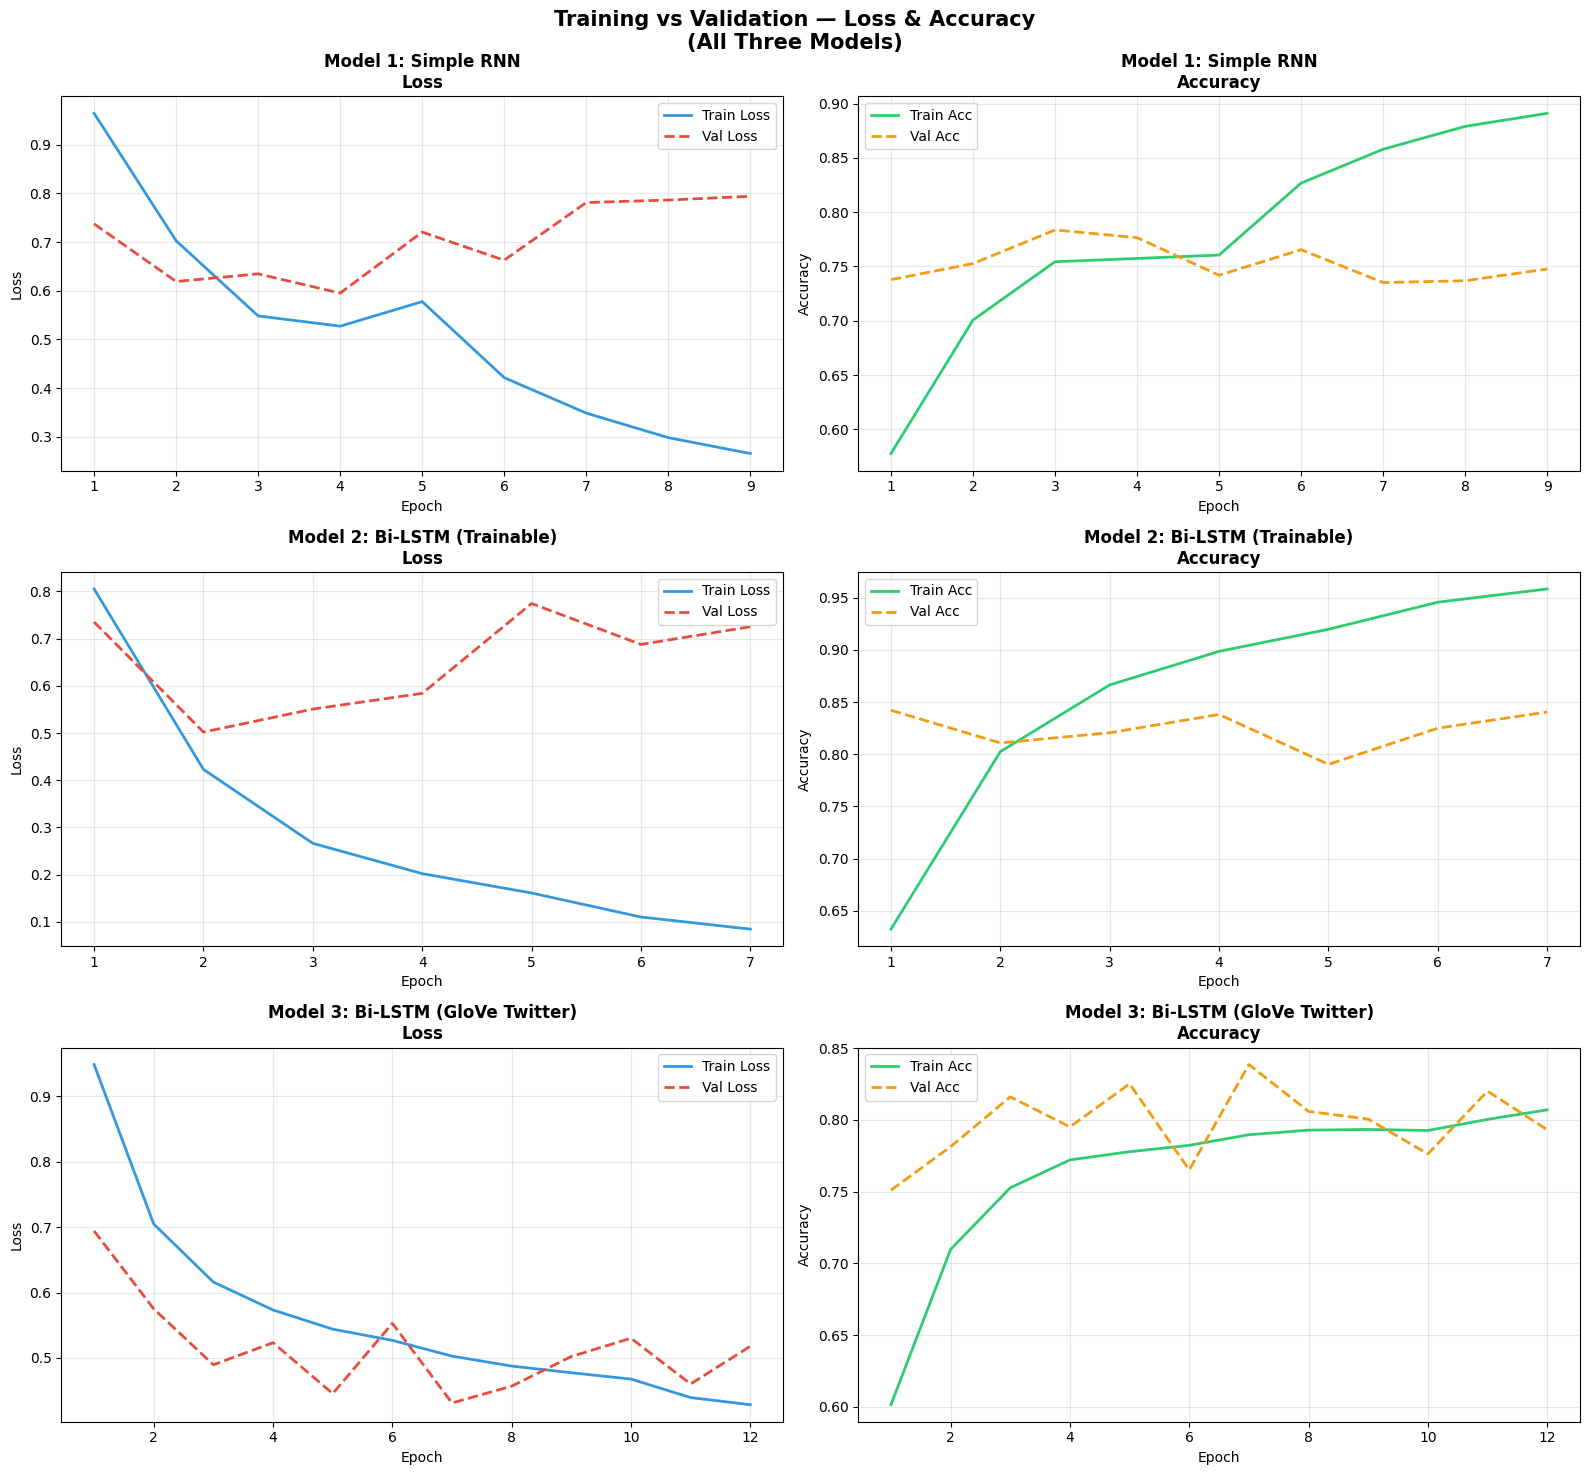


💡 Interpretation:
   - If Train Loss decreases but Val Loss increases → OVERFITTING
   - Both decreasing together → GOOD learning
   - Val line flattening while Train continues → EarlyStopping kicked in


In [25]:
# ── Plot Training Curves ───────────────────────────────────────────────────
def plot_history(history, model_name, ax_loss, ax_acc):
    """
    Plots training vs validation loss and accuracy on provided axes.
    A large gap between train and val lines indicates OVERFITTING.
    If both lines are high and close together → good generalization.
    """
    epochs_run = range(1, len(history.history['loss']) + 1)

    # Loss plot
    ax_loss.plot(epochs_run, history.history['loss'],     label='Train Loss',
                 linewidth=2, color='#3498db')
    ax_loss.plot(epochs_run, history.history['val_loss'], label='Val Loss',
                 linewidth=2, linestyle='--', color='#e74c3c')
    ax_loss.set_title(f'{model_name}\nLoss', fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    # Accuracy plot
    ax_acc.plot(epochs_run, history.history['accuracy'],     label='Train Acc',
                linewidth=2, color='#2ecc71')
    ax_acc.plot(epochs_run, history.history['val_accuracy'], label='Val Acc',
                linewidth=2, linestyle='--', color='#f39c12')
    ax_acc.set_title(f'{model_name}\nAccuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)


fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Training vs Validation — Loss & Accuracy\n(All Three Models)',
             fontsize=15, fontweight='bold')

plot_history(history1, 'Model 1: Simple RNN',             axes[0][0], axes[0][1])
plot_history(history2, 'Model 2: Bi-LSTM (Trainable)',    axes[1][0], axes[1][1])
plot_history(history3, 'Model 3: Bi-LSTM (GloVe Twitter)',axes[2][0], axes[2][1])

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Interpretation:")
print("   - If Train Loss decreases but Val Loss increases → OVERFITTING")
print("   - Both decreasing together → GOOD learning")
print("   - Val line flattening while Train continues → EarlyStopping kicked in")

---
## 🔬 Section 7: Comprehensive Evaluation (Improvement #5)

In [26]:
# ── Evaluation Helper ──────────────────────────────────────────────────────
CLASS_NAMES = list(le.classes_)

def evaluate_model(model, X_pad, y_true_cat, y_true_int, name):
    """
    Evaluates a model and prints:
    - Test Loss and Accuracy
    - Classification Report:
        Precision = of all predicted as X, how many were actually X?
        Recall    = of all actual X, how many did we catch?
        F1-Score  = harmonic mean of precision and recall
        Support   = number of actual samples in each class
    """
    loss, acc = model.evaluate(X_pad, y_true_cat, verbose=0)
    y_pred_prob = model.predict(X_pad, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)  # take highest probability class

    print("=" * 65)
    print(f" {name}")
    print("=" * 65)
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print("\nClassification Report (MACRO F1 is the key metric here):")
    print(classification_report(y_true_int, y_pred, target_names=CLASS_NAMES))

    return y_pred


y_pred1 = evaluate_model(model1, X_test_pad, y_test_cat, y_test,
                          'Model 1 — Simple RNN')
y_pred2 = evaluate_model(model2, X_test_pad, y_test_cat, y_test,
                          'Model 2 — Bi-LSTM (Trainable Emb)')
y_pred3 = evaluate_model(model3, X_test_pad, y_test_cat, y_test,
                          'Model 3 — Bi-LSTM (GloVe Twitter)')

 Model 1 — Simple RNN
  Test Loss     : 0.5726
  Test Accuracy : 78.78%

Classification Report (MACRO F1 is the key metric here):
                    precision    recall  f1-score   support

        hate speec       0.21      0.54      0.30       285
           neither       0.70      0.87      0.78       832
offensive language       0.95      0.79      0.86      3836

          accuracy                           0.79      4953
         macro avg       0.62      0.73      0.65      4953
      weighted avg       0.87      0.79      0.82      4953

 Model 2 — Bi-LSTM (Trainable Emb)
  Test Loss     : 0.4841
  Test Accuracy : 82.70%

Classification Report (MACRO F1 is the key metric here):
                    precision    recall  f1-score   support

        hate speec       0.26      0.63      0.37       285
           neither       0.78      0.86      0.82       832
offensive language       0.96      0.83      0.89      3836

          accuracy                           0.83      4953
  

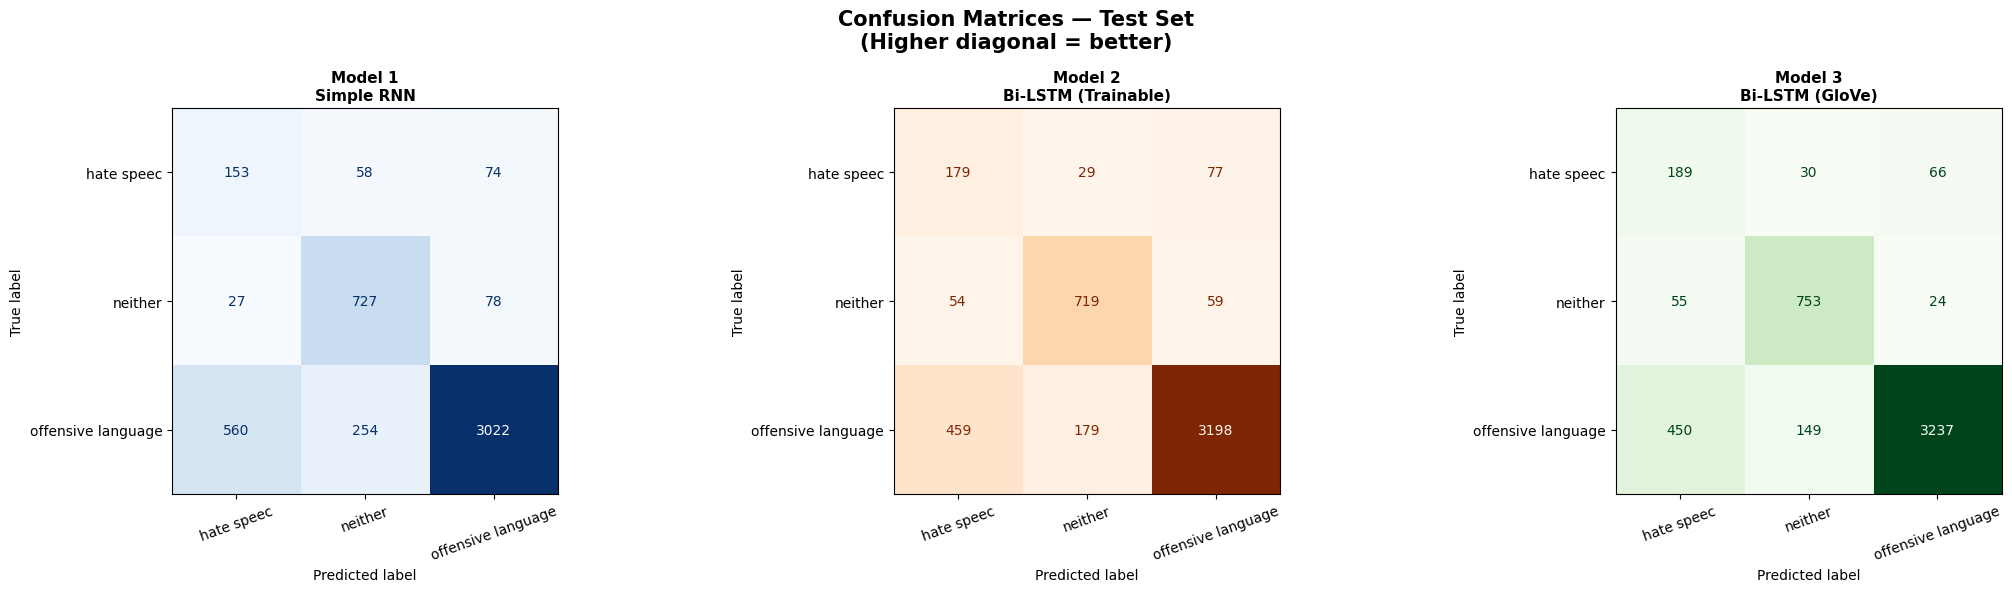

In [27]:
# ── Confusion Matrices ─────────────────────────────────────────────────────
#
# How to read a Confusion Matrix (3-class example):
#
#              Predicted
#           Hate  Off  Nei
# Actual  | 120  | 40 |  5 |  ← True class is Hate
#         |  20  |900 | 10 |  ← True class is Offensive
#         |   5  | 30 |400 |  ← True class is Neither
#
# Diagonal = CORRECT predictions
# Off-diagonal = ERRORS (what was it predicted as instead?)
# Big off-diagonal values = common confusion pairs

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Confusion Matrices — Test Set\n(Higher diagonal = better)',
             fontsize=15, fontweight='bold')

model_names = ['Model 1\nSimple RNN',
               'Model 2\nBi-LSTM (Trainable)',
               'Model 3\nBi-LSTM (GloVe)']
predictions = [y_pred1, y_pred2, y_pred3]
cmap_list   = ['Blues', 'Oranges', 'Greens']

for ax, name, y_pred, cmap in zip(axes, model_names, predictions, cmap_list):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


 FINAL MODEL COMPARISON
              Model  Test Accuracy (%)  Macro F1 (%)  Training Time (s)
         Simple RNN          78.780537     64.595266              187.4
Bi-LSTM (Trainable)          82.697355     69.199600              475.6
    Bi-LSTM (GloVe)          84.373107     71.455367              493.8

💡 Use Macro F1 as the main metric — it accounts for class imbalance.
   Accuracy alone is misleading when 77% of data is one class.


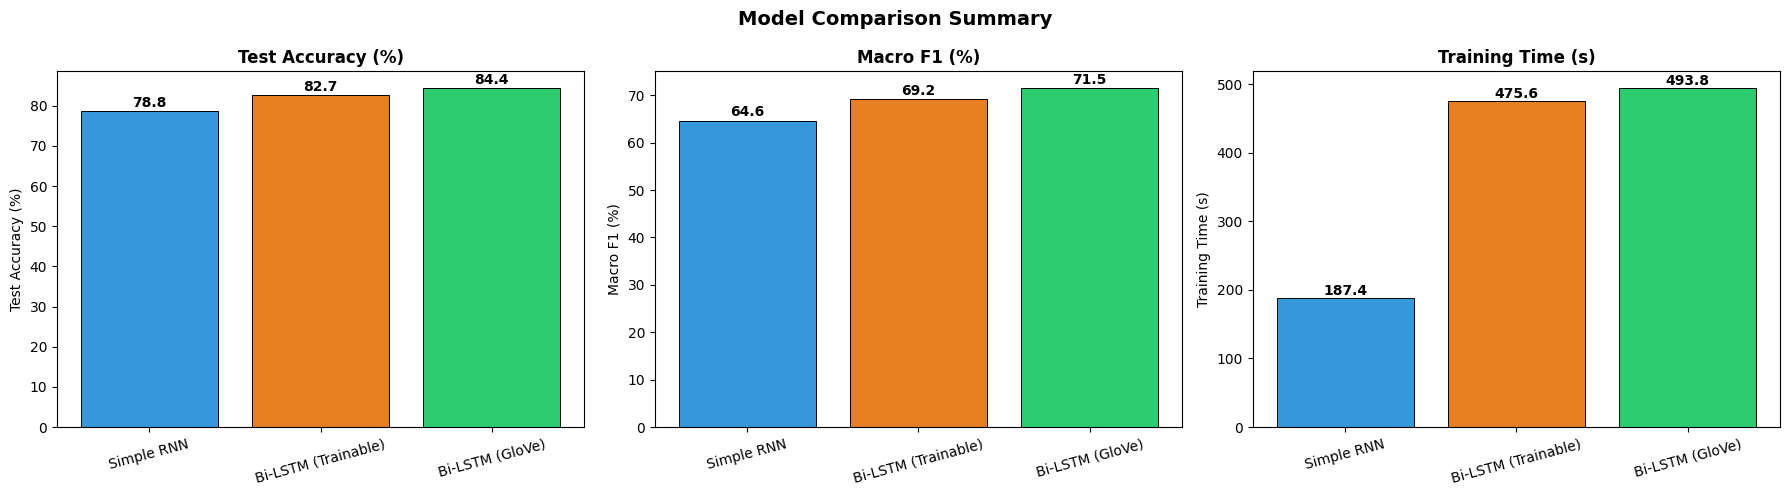

In [28]:
# ── Side-by-Side Model Comparison ─────────────────────────────────────────
results = {
    'Model': ['Simple RNN', 'Bi-LSTM (Trainable)', 'Bi-LSTM (GloVe)'],
    'Test Accuracy (%)': [
        accuracy_score(y_test, y_pred1) * 100,
        accuracy_score(y_test, y_pred2) * 100,
        accuracy_score(y_test, y_pred3) * 100,
    ],
    'Macro F1 (%)': [
        f1_score(y_test, y_pred1, average='macro') * 100,
        f1_score(y_test, y_pred2, average='macro') * 100,
        f1_score(y_test, y_pred3, average='macro') * 100,
    ],
    'Training Time (s)': [
        round(model1_train_time, 1),
        round(model2_train_time, 1),
        round(model3_train_time, 1),
    ]
}
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print(" FINAL MODEL COMPARISON")
print("=" * 70)
print(results_df.to_string(index=False))
print("\n💡 Use Macro F1 as the main metric — it accounts for class imbalance.")
print("   Accuracy alone is misleading when 77% of data is one class.")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison Summary', fontsize=14, fontweight='bold')

colors  = ['#3498db', '#e67e22', '#2ecc71']
metrics = ['Test Accuracy (%)', 'Macro F1 (%)', 'Training Time (s)']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Section 8: Error Analysis

In [29]:
# ── Error Analysis: Misclassified Examples ─────────────────────────────────
test_df = pd.DataFrame({
    'original_text': X_test,
    'true_label'   : le.inverse_transform(y_test),
    'pred_m1'      : le.inverse_transform(y_pred1),
    'pred_m2'      : le.inverse_transform(y_pred2),
    'pred_m3'      : le.inverse_transform(y_pred3),
})

misclassified_m2 = test_df[test_df['true_label'] != test_df['pred_m2']].copy()
print(f"Model 2 misclassified {len(misclassified_m2)} / {len(test_df)} samples "
      f"({len(misclassified_m2)/len(test_df)*100:.1f}%)\n")

print("=" * 80)
print("SAMPLE MISCLASSIFIED EXAMPLES (Model 2 — Bi-LSTM)")
print("=" * 80)
sample_errors = misclassified_m2.groupby('true_label').head(2).head(6)
for i, (_, row) in enumerate(sample_errors.iterrows(), 1):
    print(f"\n[Error {i}]")
    print(f"  Tweet       : {row['original_text'][:120]}")
    print(f"  True Label  : {row['true_label']}")
    print(f"  Predicted   : {row['pred_m2']}")

Model 2 misclassified 857 / 4953 samples (17.3%)

SAMPLE MISCLASSIFIED EXAMPLES (Model 2 — Bi-LSTM)

[Error 1]
  Tweet       : stop trying honky
  True Label  : offensive language
  Predicted   : neither

[Error 2]
  Tweet       : like tattoo head form mullet white trash people entertaining sometimes
  True Label  : offensive language
  Predicted   : hate speec

[Error 3]
  Tweet       : rt word make hoe rt okay sex first date long feeling mutual
  True Label  : neither
  Predicted   : offensive language

[Error 4]
  Tweet       : yep sob got hope couple national guy including kipermcshay mock slipping
  True Label  : neither
  Predicted   : offensive language

[Error 5]
  Tweet       : geez think may right monkey surely act like one
  True Label  : hate speec
  Predicted   : neither

[Error 6]
  Tweet       : rt lmfaoo never dolo got nigga old hoe fuck
  True Label  : hate speec
  Predicted   : offensive language


In [30]:
# ── Error Discussion ───────────────────────────────────────────────────────
print("""
ERROR ANALYSIS DISCUSSION
==========================

1. CLASS IMBALANCE EFFECT (SOLVED with class_weights)
   - Without class weights: models heavily bias toward 'offensive language' (77%).
   - WITH class weights: 'hate speech' errors are penalized ~5-6x more,
     improving recall for the minority class.

2. LINGUISTIC AMBIGUITY (hard to fully solve)
   - Hate speech and offensive language share profanity and slang vocabulary.
   - Without broader context (target group, intent), models confuse the two.

3. SHORT TEXT PROBLEM
   - After cleaning, many tweets reduce to only 3-5 tokens.
   - Very little contextual signal for recurrent layers.

4. MODEL 1 vs MODEL 2
   - SimpleRNN: vanishing gradients weaken learning of long-range dependencies.
   - BiLSTM: gating mechanism retains relevant context; bidirectionality
     captures both past and future context for each token.

5. MODEL 3 — PRETRAINED GLOVE TWITTER
   - Trained on 2B tweets; understands Twitter slang and abbreviations.
   - Improves recall for 'hate speech' even with frozen weights.
   - However, it requires ~200MB disk space and a longer setup time.
""")


ERROR ANALYSIS DISCUSSION

1. CLASS IMBALANCE EFFECT (SOLVED with class_weights)
   - Without class weights: models heavily bias toward 'offensive language' (77%).
   - WITH class weights: 'hate speech' errors are penalized ~5-6x more,
     improving recall for the minority class.

2. LINGUISTIC AMBIGUITY (hard to fully solve)
   - Hate speech and offensive language share profanity and slang vocabulary.
   - Without broader context (target group, intent), models confuse the two.

3. SHORT TEXT PROBLEM
   - After cleaning, many tweets reduce to only 3-5 tokens.
   - Very little contextual signal for recurrent layers.

4. MODEL 1 vs MODEL 2
   - SimpleRNN: vanishing gradients weaken learning of long-range dependencies.
   - BiLSTM: gating mechanism retains relevant context; bidirectionality
     captures both past and future context for each token.

5. MODEL 3 — PRETRAINED GLOVE TWITTER
   - Trained on 2B tweets; understands Twitter slang and abbreviations.
   - Improves recall for 'hat

---
## 🖥️ Section 9: Real-Time Prediction Interface (Gradio)

In [31]:
!pip install gradio -q
import gradio as gr
print(f"Gradio version: {gr.__version__}")

Gradio version: 5.50.0


In [32]:
def predict_tweet(tweet_text: str, selected_model: str) -> str:
    if not tweet_text.strip():
        return "⚠️ Please enter a tweet."

    cleaned = preprocess_text(tweet_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    pad     = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    model_map = {
        'Model 1: Simple RNN'              : model1,
        'Model 2: Bi-LSTM (Trainable Emb)' : model2,
        'Model 3: Bi-LSTM (GloVe Twitter)' : model3,
    }
    chosen_model = model_map[selected_model]
    probs        = chosen_model.predict(pad, verbose=0)[0]
    pred_idx     = np.argmax(probs)
    pred_label   = CLASS_NAMES[pred_idx]

    emoji_map = {
        'hate speec'        : '🚨 HATE SPEECH',
        'offensive language': '⚠️ OFFENSIVE LANGUAGE',
        'neither'           : '✅ NEITHER (Acceptable)'
    }

    result  = f"**Prediction: {emoji_map.get(pred_label, pred_label)}**\n\n"
    result += f"Cleaned text: `{cleaned}`\n\n"
    result += "**Confidence Scores:**\n"
    for cls, prob in zip(CLASS_NAMES, probs):
        bar = '█' * int(prob * 20)
        result += f"- `{cls:22s}` : {prob*100:5.1f}%  {bar}\n"
    return result


demo = gr.Interface(
    fn=predict_tweet,
    inputs=[
        gr.Textbox(lines=3, placeholder="Enter a tweet here...", label="Tweet Text"),
        gr.Radio(
            choices=['Model 1: Simple RNN',
                     'Model 2: Bi-LSTM (Trainable Emb)',
                     'Model 3: Bi-LSTM (GloVe Twitter)'],
            value='Model 3: Bi-LSTM (GloVe Twitter)',
            label="Select Model"
        )
    ],
    outputs=gr.Markdown(label="Prediction Result"),
    title="🔍 Hate Speech Detector",
    description="Classifies a tweet as Hate Speech, Offensive Language, or Neither.\n"
                "Built for 6CS012 – Herald College, Kathmandu.",
    examples=[
        ["I love spending time with my family and friends!", "Model 2: Bi-LSTM (Trainable Emb)"],
        ["That was a terrible play, this team is awful!",    "Model 3: Bi-LSTM (GloVe Twitter)"],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c8bca88dbaa58a6723.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 📋 Section 10: Summary and Viva Cheat Sheet

In [33]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║          FINAL MODEL COMPARISON — 6CS012 NLP Task               ║
║          Herald College Kathmandu                                ║
╚══════════════════════════════════════════════════════════════════╝
""")
print(results_df.to_string(index=False))

print("""

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📖 VIVA CHEAT SHEET — Key Concepts to Explain
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Q: What is Bidirectional LSTM?
A: It runs two LSTMs — one left-to-right, one right-to-left — and
   concatenates their outputs. Every word gets context from BOTH
   directions, improving understanding of word meaning in context.

Q: What is the Embedding Matrix?
A: A lookup table (shape: vocab_size × embed_dim) where each row is
   the vector for a word. For pretrained embeddings, we copy GloVe's
   Twitter vectors into the rows matching our tokenizer's word indices.

Q: Why use class_weight?
A: Our dataset is 77% offensive language. Without correction, the model
   learns to ignore 'hate speech' (only 5.8%). class_weight makes
   minority-class errors count more in the loss calculation.

Q: Why use EarlyStopping?
A: It monitors validation loss and stops training when it stops
   improving (for 'patience' epochs). This prevents overfitting and
   saves computation time.

Q: Why Macro F1 instead of Accuracy?
A: Accuracy is misleading with imbalanced data (a 77% accuracy could
   mean the model just always predicts 'offensive'). Macro F1 averages
   F1 equally across all classes, giving minority classes equal weight.

Q: What is Lemmatization?
A: Reducing a word to its base/dictionary form.
   'running' → 'run', 'better' → 'good', 'cars' → 'car'
   Reduces vocabulary size and groups related word forms together.

Q: Why freeze GloVe embeddings (trainable=False)?
A: GloVe already learned high-quality representations from 2B tweets.
   Our small dataset could corrupt those representations if we allow
   updates. Freezing preserves the pretrained knowledge.
""")


╔══════════════════════════════════════════════════════════════════╗
║          FINAL MODEL COMPARISON — 6CS012 NLP Task               ║
║          Herald College Kathmandu                                ║
╚══════════════════════════════════════════════════════════════════╝

              Model  Test Accuracy (%)  Macro F1 (%)  Training Time (s)
         Simple RNN          78.780537     64.595266              187.4
Bi-LSTM (Trainable)          82.697355     69.199600              475.6
    Bi-LSTM (GloVe)          84.373107     71.455367              493.8


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📖 VIVA CHEAT SHEET — Key Concepts to Explain
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Q: What is Bidirectional LSTM?
A: It runs two LSTMs — one left-to-right, one right-to-left — and
   concatenates their outputs. Every word gets context from BOTH
   directions, improving understanding of word meaning in context.

Q: What is the Embedding Matrix?
A: A lookup table (shape: 